# Downscaling Wind Speed for NYC **Tristate** area

**Variables:**
* Variable to be downscaled: Wind Speed (WS)
* Predictor variable: Surface Pressure (PSFC) 

**Dataset Resolutions:**
* uWRF (Domain 02): 3-hourly, 3 km
* NAM: 3-hourly, 12 km

**Spatial Coverage:**
* 115,291.16 km²

In [1]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import dl4d as dds
#import dl4ds as dds
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import models

2025-06-04 12:19:39.824307: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-04 12:19:40.038001: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/compiler/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/libfabric/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib/release:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib:/software1/intel/2020_

In [2]:
!python --version
#Should be Python 3.8.18

Python 3.7.12


In [3]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [4]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [5]:
uwrf_train

<xarray.Dataset>
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (y, x) float32 ...
    longitude  (y, x) float32 ...
  * time       (time) datetime64[ns] 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 ...
    PSFC       (time, y, x) float32 ...
    U10        (time, y, x) float32 ...
    V10        (time, y, x) float32 ...
    SWDOWN     (time, y, x) float32 ...
    PBLH       (time, y, x) float32 ...
    HGT        (time, y, x) float32 ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [6]:
nam_train

<xarray.Dataset>
Dimensions:    (time: 2697, y: 40, x: 40)
Coordinates:
  * y          (y) float64 1.219e+04 2.438e+04 3.657e+04 ... 4.754e+05 4.876e+05
  * x          (x) float64 3.292e+05 3.413e+05 3.535e+05 ... 7.924e+05 8.046e+05
    latitude   (y, x) float64 ...
    longitude  (y, x) float64 ...
  * time       (time) datetime64[ns] 2019-01-01 ... 2019-04-14T03:00:00
Data variables:
    T2         (time, y, x) float32 ...
    PSFC       (time, y, x) float32 ...
    U10        (time, y, x) float32 ...
    V10        (time, y, x) float32 ...
    SWDOWN     (time, y, x) float32 ...
    PBLH       (time, y, x) float32 ...
    HGT        (time, y, x) float32 ...
Attributes:
    Conventions:          CF-1.0
    History:              created by wgrib2
    GRIB2_grid_template:  30

# Manually calculate Wind Speed

In [8]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

            # Keep only PSFC and WS
            new_ds = ds[['PSFC', 'WS']]

for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

            # Keep only PSFC and WS
            new_ds = ds[['PSFC', 'WS']]



In [9]:
uwrf_train

<xarray.Dataset>
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (y, x) float32 39.84 39.83 39.82 39.81 ... 42.04 42.03 42.02
    longitude  (y, x) float32 -76.7 -76.67 -76.64 -76.6 ... -71.29 -71.25 -71.22
  * time       (time) datetime64[ns] 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 ...
    PSFC       (time, y, x) float32 ...
    U10        (time, y, x) float32 -1.981 -2.044 -2.099 ... 2.669 1.553 1.525
    V10        (time, y, x) float32 2.25 2.206 2.152 2.09 ... 3.783 1.914 1.966
    SWDOWN     (time, y, x) float32 ...
    PBLH       (time, y, x) float32 ...
    HGT        (time, y, x) float32 ...
    WS         (time, y, x) float32 2.998 3.007 3.007 3.0 ... 4.63 2.465 2.488
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [10]:
nam_train

<xarray.Dataset>
Dimensions:    (time: 2697, y: 40, x: 40)
Coordinates:
  * y          (y) float64 1.219e+04 2.438e+04 3.657e+04 ... 4.754e+05 4.876e+05
  * x          (x) float64 3.292e+05 3.413e+05 3.535e+05 ... 7.924e+05 8.046e+05
    latitude   (y, x) float64 39.22 39.2 39.19 39.17 ... 42.69 42.67 42.66 42.64
    longitude  (y, x) float64 -77.09 -76.96 -76.82 ... -71.17 -71.03 -70.89
  * time       (time) datetime64[ns] 2019-01-01 ... 2019-04-14T03:00:00
Data variables:
    T2         (time, y, x) float32 ...
    PSFC       (time, y, x) float32 ...
    U10        (time, y, x) float32 -0.6768 -0.4568 -0.4768 ... 1.997 2.237
    V10        (time, y, x) float32 0.7544 0.3444 0.1144 ... 3.538 3.798 4.328
    SWDOWN     (time, y, x) float32 ...
    PBLH       (time, y, x) float32 ...
    HGT        (time, y, x) float32 ...
    WS         (time, y, x) float32 1.014 0.5721 0.4904 ... 3.968 4.291 4.872
Attributes:
    Conventions:          CF-1.0
    History:              created by wgrib2
    GRIB2_grid_template:  30

In [11]:
#High resolution (uWRF) data
WS_hr_train = uwrf_train.WS
WS_hr_val = uwrf_val.WS
WS_hr_test = uwrf_test.WS

PSFC_hr_train = uwrf_train.PSFC
PSFC_hr_val = uwrf_val.PSFC
PSFC_hr_test = uwrf_test.PSFC

#--------------------------
#Low resolution (NAM) data
WS_lr_train = nam_train.WS
WS_lr_val = nam_val.WS
WS_lr_test = nam_test.WS

PSFC_lr_train = nam_train.PSFC
PSFC_lr_val = nam_val.PSFC
PSFC_lr_test = nam_test.PSFC

In [12]:
WS_scaler_train = dds.StandardScaler(axis=None)
WS_scaler_train.fit(WS_hr_train)  

PSFC_scaler_train = dds.StandardScaler(axis=None)
PSFC_scaler_train.fit(PSFC_hr_train)
#----------------------------------------------
#High resolution (uWRF):
y_train = WS_scaler_train.transform(WS_hr_train)
y_val = WS_scaler_train.transform(WS_hr_val)
y_test = WS_scaler_train.transform(WS_hr_test)


y_z_train = PSFC_scaler_train.transform(PSFC_hr_train)
y_z_val = PSFC_scaler_train.transform(PSFC_hr_val)
y_z_test = PSFC_scaler_train.transform(PSFC_hr_test)

#-------------------------------------------------
#Low resolution (NAM)

x_train = WS_scaler_train.transform(WS_lr_train)
x_val = WS_scaler_train.transform(WS_lr_val)
x_test = WS_scaler_train.transform(WS_lr_test)

x_z_train = PSFC_scaler_train.transform(PSFC_lr_train)
x_z_val = PSFC_scaler_train.transform(PSFC_lr_val)
x_z_test = PSFC_scaler_train.transform(PSFC_lr_test)

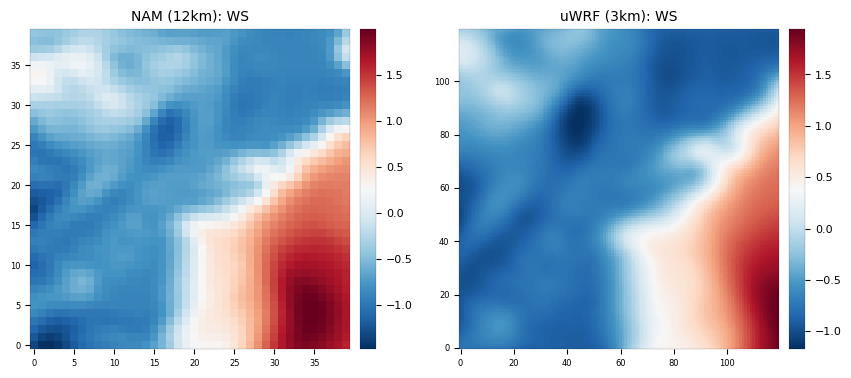

In [13]:
#WS: Wind Speed
ecv.plot((x_train[0].values, y_train[0]), subplot_titles=('NAM (12km): WS', 'uWRF (3km): WS'))

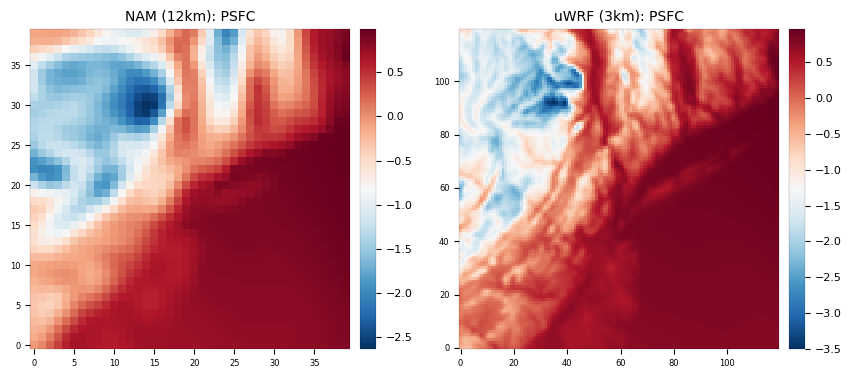

In [14]:
#PSFC: Surface Pressure
ecv.plot((x_z_train[0].values, y_z_train[0]), subplot_titles=('NAM (12km): PSFC', 'uWRF (3km): PSFC'))

In [15]:
y_train = y_train.expand_dims(dim='channel', axis=-1)
y_val = y_val.expand_dims(dim='channel', axis=-1)
y_test = y_test.expand_dims(dim='channel', axis=-1)

y_z_train = y_z_train.expand_dims(dim ='channel', axis=-1)
y_z_val = y_z_val.expand_dims(dim ='channel', axis=-1)
y_z_test = y_z_test.expand_dims(dim ='channel', axis=-1)

#-----------------------------------------------------

x_train = x_train.expand_dims(dim='channel', axis=-1)
x_val = x_val.expand_dims(dim='channel', axis=-1)
x_test = x_test.expand_dims(dim='channel', axis=-1)

x_z_train = x_z_train.expand_dims(dim ='channel', axis=-1)
x_z_val = x_z_val.expand_dims(dim ='channel', axis=-1)
x_z_test = x_z_test.expand_dims(dim ='channel', axis=-1)

In [16]:
print("WS hr data shape:")
print(y_train.shape, y_val.shape, y_test.shape)
print("")
print("PSFC hr data shape:")
print(y_z_train.shape, y_z_val.shape, y_z_test.shape)
print("")
print("WS lr data shape:")
print(x_train.shape, x_val.shape, x_test.shape)
print("")
print("PSFC lr data shape:")
print(x_z_train.shape, x_z_val.shape, x_z_test.shape)

WS hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

PSFC hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

WS lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

PSFC lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)


Running model with backbone=resnet, filters=8, blocks=8, epochs=76
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Running model with backbone=resnet, filters=8, blocks=8, epochs=76
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Checking if model has already been tested: ('WS', 'PSFC', 'resnet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', '76', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-04 12:21:26
--------------------------------------------------------------------------------


2025-06-04 12:21:26.922468: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/gvaillant1/.conda/envs/dl4d/lib/python3.7/site-packages/cv2/../../lib64:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/compiler/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/libfabric/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib/release:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/ipp/lib/intel64:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mkl/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/tbb/lib/intel64/gcc4.8:/software1/intel/2020_up

Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 input_1 (InputLayer)                            [(None, 40, 40, 2)]              0                 []                                                
                                                                                                                                                      
 conv2d (Conv2D)                                 (None, 40, 40, 8)                152               ['input_1[0][0]']                                 
                                                                                                                                                      
 ResidualBlock1 (ResidualBlock)                  (None, 40, 40, 8)        

44/44 [==============================] - 118s 2s/step - loss: 0.8204 - val_loss: 0.7132
Epoch 2/76
44/44 [==============================] - ETA: 0s - loss: 0.6448

44/44 [==============================] - 110s 3s/step - loss: 0.6448 - val_loss: 0.3771
Epoch 3/76
44/44 [==============================] - ETA: 0s - loss: 0.3962

...

44/44 [==============================] - 103s 2s/step - loss: 0.1561 - val_loss: 0.1065
Epoch 52/76
44/44 [==============================] - ETA: 0s - loss: 0.1552

44/44 [==============================] - 106s 2s/step - loss: 0.1552 - val_loss: 0.1067
Epoch 53/76
44/44 [==============================] - ETA: 0s - loss: 0.1553

44/44 [==============================] - 107s 2s/step - loss: 0.1553 - val_loss: 0.1062
Epoch 54/76
44/44 [==============================] - ETA: 0s - loss: 0.1555

44/44 [==============================] - 104s 2s/step - loss: 0.1555 - val_loss: 0.1099
Epoch 55/76
44/44 [==============================] - ETA: 0s - loss: 0.1547

44/44 [==============================] - 104s 2s/step - loss: 0.1547 - val_loss: 0.1091
Epoch 55: early stopping
9/9 [==============================] - 3s 345ms/step - loss: 0.1017

Score on the test set: 0.10173175483942032
--------------------------------------------------------------------------------
Final running time: 1:38:08.185816
--------------------------------------------------------------------------------


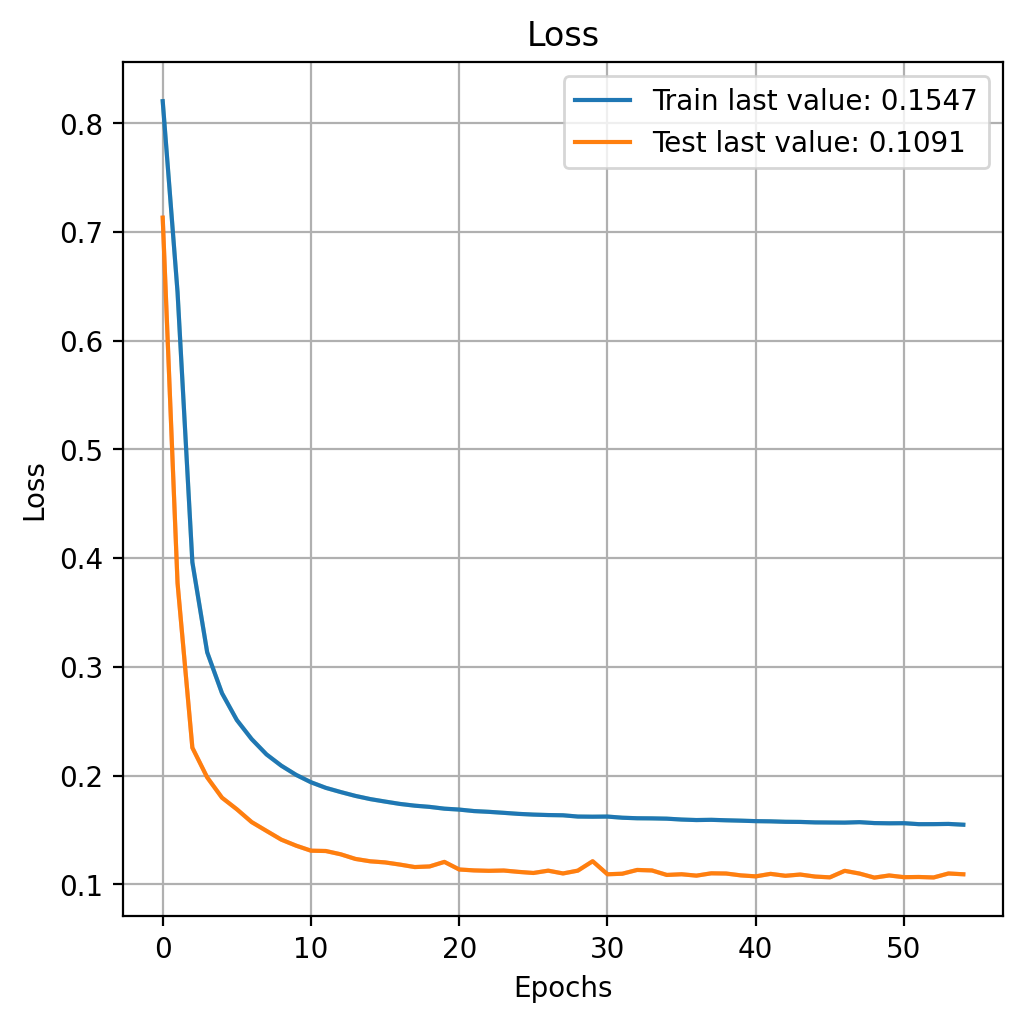

Moved to best model directory
Training complete


In [17]:
import os
import shutil
import csv
import pandas as pd

PSFC_train = [y_z_train]
PSFC_val = [y_z_val]
PSFC_test = [y_z_test]

#------------------------------------------------------------------------------------
results = []
best_loss = float('inf')
best_model_path = "/home/gvaillant1/downscaling/pretrained-models/WS-Best-Model" #**change**
other_models_path = "/home/gvaillant1/downscaling/pretrained-models/WS-Other-Models" #**change**
test_loss_file = os.path.join(other_models_path, "test_loss.txt")
runtime_file = os.path.join(other_models_path, "running_time.txt")
csv_file = "/home/gvaillant1/downscaling/results/WS_model_results.csv" #**change**
results = pd.read_csv(csv_file)
#------------------------------------------------------------------------------------
#TESTING DIFFERENT HYPER PARAMETERS:
#change the hyperparams to test different models
backbones = ['resnet']
num_filters = [8] 
num_blocks = [8]
epochs = [76]
lrate_values = (1e-3, 1e-4)
local_layer=True
#------------------------------------------------------------------------------------

#Check the existing results csv file to see if the parameter combination has already been tested
existing_results = []
if os.path.exists(csv_file):
    with open(csv_file, "r") as f:
        reader = csv.reader(f)
        next(reader, None)  # Skip header
        for row in reader:
            existing_results.append(tuple(row))

# Retrieve the lowest loss from CSV before training
if existing_results:
    best_loss = min(float(row[2]) for row in existing_results if row[2] != "NULL")

min_losses = {}

for backbone in backbones:
    for filters in num_filters:
        for blocks in num_blocks:
            for epoch in epochs:
                for lr in lrate_values:
                    ARCH_PARAMS = dict(n_filters=filters,
                                       n_blocks=blocks,
                                       normalization=None,
                                       dropout_rate=0.5,
                                       dropout_variant='spatial',
                                       attention=False,
                                       activation='relu',
                                       localcon_layer=local_layer)
        
                    print(f"Running model with backbone={backbone}, filters={filters}, blocks={blocks}, epochs={epoch}")
        
                    trainer = dds.SupervisedTrainer(
                        backbone=backbone,
                        upsampling='spc',
                        data_train=y_train,
                        data_val=y_val,
                        data_test=y_test,
                        data_train_lr=None,
                        data_val_lr=None,
                        data_test_lr=None,
                        scale=3,
                        time_window=None,
                        static_vars=None,
                        predictors_train=PSFC_train, #Add predictor information here (not required)
                        predictors_val=PSFC_val, #Add predictor information here (not required)
                        predictors_test=PSFC_test, #Add predictor informatio here (not required)
                        interpolation='inter_area',
                        patch_size=None,
                        batch_size=60,
                        loss='mae',
                        epochs=epoch,
                        steps_per_epoch=None,
                        validation_steps=None,
                        test_steps=None,
                        learning_rate=lr,
                        lr_decay_after=1e4,
                        early_stopping=True,
                        patience=6,
                        min_delta=0,
                        save=True,
                        save_bestmodel=True,
                        save_path=other_models_path,
                        show_plot=True,
                        verbose=True,
                        device='CPU',
                        **ARCH_PARAMS)
    
                # Create unique model identifier (ensure all fields match CSV format)
                #Needed to specify the datatypes so the code will be able to correctly check if we have done the model before
                model_id = (str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                            backbone, str(filters), str(blocks), str(lrate_values), trainer.interpolation, trainer.upsampling, 
                            str(trainer.epochs), trainer.loss, str(trainer.early_stopping), str(local_layer), str(trainer.device))
    
                model_id = (
                    str(y_train.name),
                    "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                    backbone,
                    str(filters),
                    str(blocks),
                    str(lrate_values),
                    trainer.interpolation,
                    trainer.upsampling,
                    str(trainer.epochs),
                    trainer.loss,
                    str(trainer.early_stopping),
                    str(local_layer),
                    str(trainer.device)
                )
    
                print(f"Checking if model has already been tested: {model_id}")
    
                #Check if model already exists in CSV
                model_exists = False
                for row in existing_results:
                    existing_model_id = (row[0], row[1], row[3], row[4], row[5], row[11], 
                                         row[9], row[8], row[6], row[12], row[13], row[16], row[17])
                    #print(f"Comparing with existing model: {existing_model_id}")
                    
                    if existing_model_id == model_id:
                        print("Match found! Skipping training for:", model_id)
                        model_exists = True
                        break
                
                if model_exists:
                    continue

                trainer.run()
    
                if os.path.exists(test_loss_file):
                    with open(test_loss_file, "r") as f:
                        val_loss = float(f.read().strip())
                else:
                    val_loss = float('inf')
    
                if os.path.exists(runtime_file):
                    with open(runtime_file, "r") as f:
                        training_runtime = f.read().strip()
                else:
                    training_runtime = "NULL"

                model_save_path = other_models_path  # Default save path

                #Check if the loss we just calculated is the lowest
                #If so, it is the best model and it should be put in the best model directory
                
                
                #Set the dictionary holding the lowest loss values.
                #This assumes that the results file has some data in it already
                for ele in results['Loss Function'].unique():
                    value = results.loc[results['Loss Function'] == ele, 'Test Loss'].values
                    min_losses[ele] = min(value)
                
                for key, value in min_losses.items():
                    if trainer.loss == key and val_loss < value:
                        min_losses[trainer.loss] = val_loss
                
                #print(min_losses)
                
                
                    # Remove previous best model completely before replacing it
                        if os.path.exists(best_model_path):
                            shutil.rmtree(best_model_path)  # Delete the entire directory
    
                        # Move new best model to the best model directory
                        shutil.move(other_models_path, best_model_path)
                        model_save_path = best_model_path #replace the model_save_path with the best model path if it has a lower loss
                        print('Moved to best model directory')

                    results = results.append(
                                pd.DataFrame([[
                                    str(y_train.name), 
                                    "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                    val_loss, 
                                    backbone, 
                                    filters, 
                                    blocks, 
                                    trainer.epochs, 
                                    trainer.model.count_params(), 
                                    trainer.upsampling, 
                                    trainer.interpolation, 
                                    trainer.batch_size, 
                                    lrate_values, 
                                    trainer.loss, 
                                    trainer.early_stopping, 
                                    training_runtime, 
                                    model_save_path, 
                                    local_layer, 
                                    trainer.device
                                ]], columns=["Downscaled Variable", "Predictor", "Test Loss",
                                             "Backbone", "Filters", "Blocks",
                                             "Epochs", "Parameters", "Upsampling Method",
                                             "Interpolation Method", "Batch Size", "Learning Rate",
                                             "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                            )



                #Write the information about the model and results in the results CSV file
                file_exists = os.path.isfile(csv_file)
                with open(csv_file, mode='a', newline='') as f:
                    writer = csv.writer(f)
                    if not file_exists:
                        writer.writerow(["Downscaled Variable", "Predictor", "Test Loss",
                                         "Backbone", "Filters", "Blocks",
                                        "Epochs", "Parameters", "Upsampling Method",
                                         "Interpolation Method", "Batch Size", "Learning Rate",
                                        "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                    writer.writerow([str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                     val_loss, backbone, filters, blocks,
                                     trainer.epochs, trainer.model.count_params(), trainer.upsampling,
                                     trainer.interpolation, trainer.batch_size, lrate_values, 
                                     trainer.loss, trainer.early_stopping, training_runtime, model_save_path, local_layer, trainer.device])
                
print("Training complete")

In [22]:
pred = dds.Predictor(
    trainer, 
    y_test, 
    scale=3, 
    array_in_hr=True,
    static_vars=None, 
    predictors=[y_z_test], 
    time_window=None,
    interpolation='inter_area', 
    batch_size=64,
    scaler=WS_scaler_train,
    save_path=None,
    save_fname=None,
    return_lr=True,
    device='CPU')

unscaled_y_pred, coarsened_array = pred.run()

--------------------------------------------------------------------------------
Starting time: 2025-06-04 14:23:54
--------------------------------------------------------------------------------
10/10 [==============================] - 5s 405ms/step
--------------------------------------------------------------------------------
Final running time: 0:00:06.981665
--------------------------------------------------------------------------------


In [23]:
pred1 = dds.Predictor(
    trainer, 
    x_train, 
    scale=4, 
    array_in_hr=False,
    static_vars=None, 
    predictors=[x_z_train], 
    time_window=None,
    interpolation='inter_area', 
    batch_size=3,
    scaler=WS_scaler_train,
    save_path=None,
    save_fname=None,
    return_lr=True,
    device='CPU')

unscaled_x_pred, coarsened_array1 = pred1.run()

--------------------------------------------------------------------------------
Starting time: 2025-06-04 14:24:01
--------------------------------------------------------------------------------
899/899 [==============================] - 74s 83ms/step
--------------------------------------------------------------------------------
Final running time: 0:01:16.310031
--------------------------------------------------------------------------------


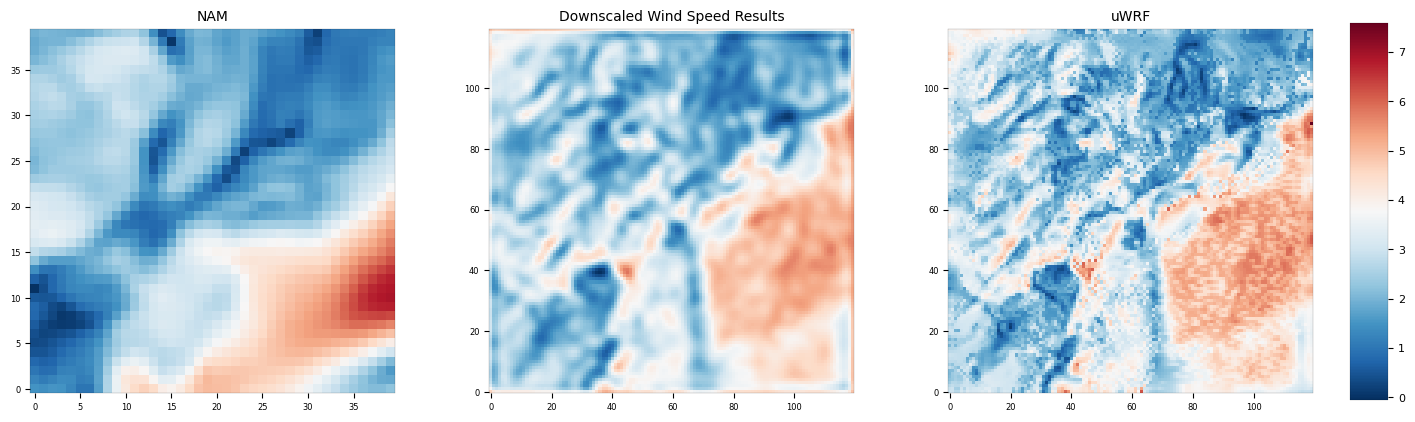

MAE for test set: 0.27541154623031616


In [24]:
unscaled_x_test = WS_scaler_train.inverse_transform(x_test)
unscaled_y_test = WS_scaler_train.inverse_transform(y_test)
ecv.plot((unscaled_x_test[1].values, unscaled_y_pred[1], unscaled_y_test[1].values),
         share_colorbar=True, share_dynamic_range=True, show_coastline=True, subplot_titles=('NAM', 'Downscaled Wind Speed Results', 'uWRF'))

mae = dds.losses.mae(unscaled_y_test[0].values, unscaled_y_pred[0])
print(f"MAE for test set: {mae}")

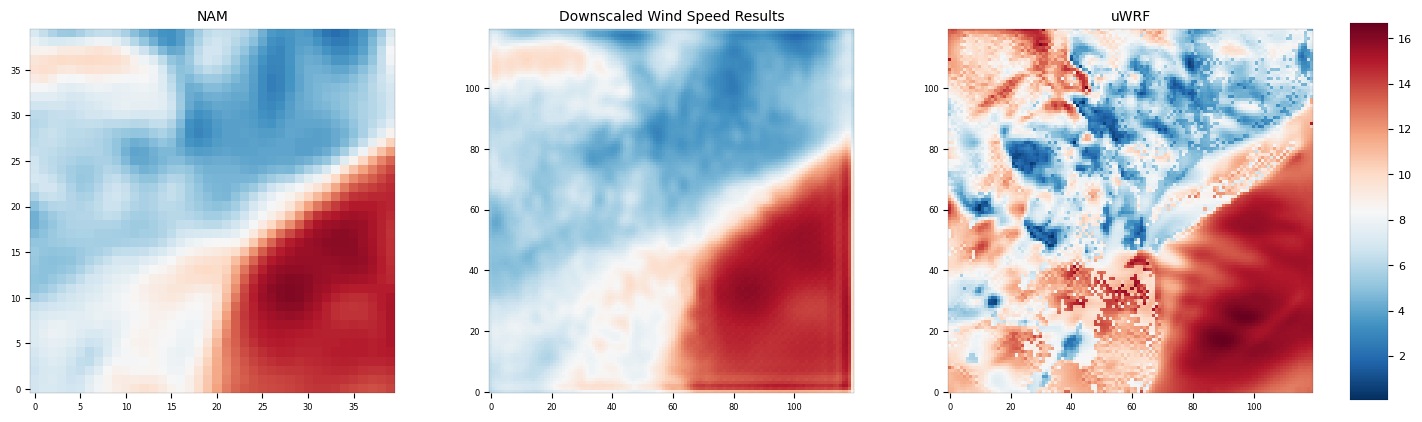

In [35]:
unscaled_x_train = WS_scaler_train.inverse_transform(x_train)
unscaled_y_train = WS_scaler_train.inverse_transform(y_train)
ecv.plot((unscaled_x_train[3].values, unscaled_x_pred[3], unscaled_y_train[3].values),
         share_colorbar=True, share_dynamic_range=True, subplot_titles=('NAM', 'Downscaled Wind Speed Results', 'uWRF'))

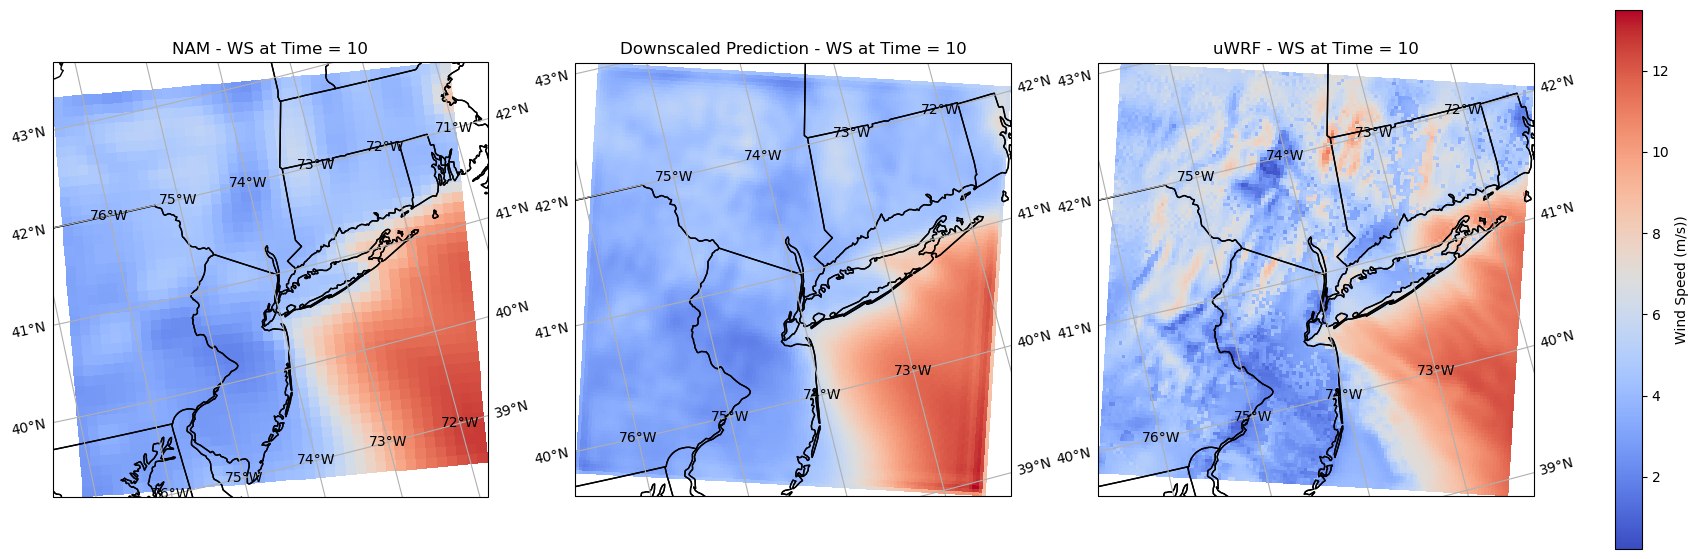

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cartopy.feature as cfeature

# Extract data
nam = unscaled_x_train  # NAM
results = unscaled_x_pred  # Predicted output (numpy array)
uwrf = unscaled_y_train  # uWRF (truth)

min_lat = 38.88588
max_lat = 43.029186
min_lon = -76.70499
max_lon = -71.21628


# Select time index
time_idx = 10 # you can change this

# Extract values
lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
WS_nam = nam[time_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
WS_uwrf = uwrf[time_idx,:,:].values

# Prediction values — assume same resolution as uWRF
WS_pred = results[time_idx, :, :]  # or results[0,:,:] if only one timestep

# Determine common color limits
vmin = min(WS_nam.min(), WS_pred.min(), WS_uwrf.min())
vmax = max(WS_nam.max(), WS_pred.max(), WS_uwrf.max())

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im0 = axes[0].pcolormesh(lon_nam, lat_nam, WS_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM - WS at Time = {time_idx}')
axes[0].coastlines()
axes[0].gridlines(draw_labels=True)
axes[0].add_feature(cfeature.STATES)
#axes[0].set_extent([lon_nam+0.1, lat_nam+0.1], crs=ccrs.PlateCarree())
#or use .LambertConformal()
# Plot Prediction
im1 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, WS_pred, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'Downscaled Prediction - WS at Time = {time_idx}')
axes[1].coastlines()
axes[1].gridlines(draw_labels=True)
axes[1].add_feature(cfeature.STATES)

# Plot uWRF
im2 = axes[2].pcolormesh(lon_uwrf, lat_uwrf, WS_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[2].set_title(f'uWRF - WS at Time = {time_idx}')
axes[2].coastlines()
axes[2].gridlines(draw_labels=True)
axes[2].add_feature(cfeature.STATES)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Wind Speed (m/s))')




plt.show()

In [33]:
import xarray as xr
import numpy as np

# Load the uWRF dataset (for coordinates)
uwrf = xr.open_dataset("/D4/data/gvaillant/uwrf-split/uwrf_train.nc")

# Extract coordinates
lat = uwrf["latitude"].isel(time=0).values  # shape (120, 120)
lon = uwrf["longitude"].isel(time=0).values  # shape (120, 120)
time = uwrf["time"].values[:2697]  # shape (578,) — match time length of results

# Create dataset from downscaled results
ds = xr.Dataset(
    {
        "WS_downscaled": (["time", "y", "x"], results)
    },
    coords={
        "time": ("time", time),
        "lat": (["y", "x"], lat),
        "lon": (["y", "x"], lon),
    }
)

# Add optional metadata
ds["WS_downscaled"].attrs["units"] = "m/s"  # or whatever is correct
ds["WS_downscaled"].attrs["long_name"] = "Downscaled Wind Speed"

# Save to NetCDF
output_path = "/home/gvaillant1/WS_downscaled_output.nc"
ds.to_netcdf(output_path)




In [34]:
data = xr.open_dataset('/home/gvaillant1/WS_downscaled_output.nc')

data

<xarray.Dataset>
Dimensions:        (time: 2697, y: 120, x: 120)
Coordinates:
  * time           (time) datetime64[ns] 2019-01-01 ... 2019-04-14T03:00:00
    lat            (y, x) float32 ...
    lon            (y, x) float32 ...
Dimensions without coordinates: y, x
Data variables:
    WS_downscaled  (time, y, x) float32 ...